# Carroll/Deaton lifecycle consumption-savings

A finite-lived household with deterministic risk-free returns, stochastic
labour income, CRRA utility, and a **borrowing constraint**. There's no
closed form; the qualitative signature is a *kinked* consumption function
at low cash-on-hand.

## Problem

State: cash-on-hand $m_t$ (wealth + current income). Action:
consumption $c_t \in [0, m_t]$ (the binding upper bound is the no-borrowing
constraint). Dynamics:

$$ m_{t+1} = R\,(m_t - c_t) + y_{t+1}, \qquad y_{t+1} = \mu_y + \sigma_y\,\varepsilon_{t+1}, \quad \varepsilon \sim \mathcal{N}(0,1). $$

Reward: CRRA utility with risk aversion $\gamma$:

$$ u(c) = \frac{c^{1-\gamma}}{1-\gamma}. $$

Objective: maximise $\sum_{t=0}^{T-1} \beta^t\,u(c_t)$ with $R\beta < 1$
(impatient household). The expected behaviour:

- **Below the buffer-stock target**, the borrowing constraint binds:
  $c_t \approx m_t$ and MPC $\approx 1$.
- **Above the target**, the household saves: $c_t < m_t$, MPC $< 1$
  (typically 0.1 – 0.5 in standard calibrations).
- Forward-simulated wealth accumulates from low initial cash toward a
  stationary buffer-stock distribution.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from bellgrid import (
    ContinuousAction,
    ContinuousState,
    Problem,
    simulate,
    solve,
)
from bellgrid.grids import RegularGrid, WarpedGrid
from bellgrid.shocks import Normal
from bellgrid.solvers import BackwardInduction

## Parameters

In [2]:
gamma = 2.0    # CRRA risk aversion
R = 1.04       # gross risk-free return
beta = 0.94    # discount factor (R*beta = 0.978 < 1 → impatient → buffer-stock saver)
mu_y = 1.0     # mean labor income
sigma_y = 0.1  # income innovation std
T = 25         # life-cycle horizon

## Bellgrid problem

In [3]:
def transition(state, action, shock, _t):
    savings = state["cash"] - action["consume"]
    next_income = mu_y + sigma_y * shock["z"]
    return {"cash": R * savings + next_income}


def reward(_state, action, _shock, _t):
    c = action["consume"]
    if gamma == 1.0:
        return torch.log(c)
    return (c ** (1.0 - gamma)) / (1.0 - gamma)


problem = Problem(
    states=[ContinuousState("cash", warp="asinh", range=(0.5, 20.0))],
    actions=[ContinuousAction("consume", bounds=(1e-4, "cash"))],
    transition=transition,
    reward=reward,
    shocks=[Normal("z", sigma=1.0)],
    horizon=range(0, T),
    discount=beta,
)

policy, value = solve(
    problem,
    state_grid={"cash": WarpedGrid(n=128)},
    action_grid={"consume": RegularGrid(n=500)},
    solver=BackwardInduction(n_quad=7),
)

## Kinked consumption function

At low cash the constraint $c \le m$ binds and the household consumes
essentially all of it (red dashed 45° line). Above the buffer-stock
threshold the household saves and the curve bends away from the 45°
line. The kink is the headline qualitative feature of the model.

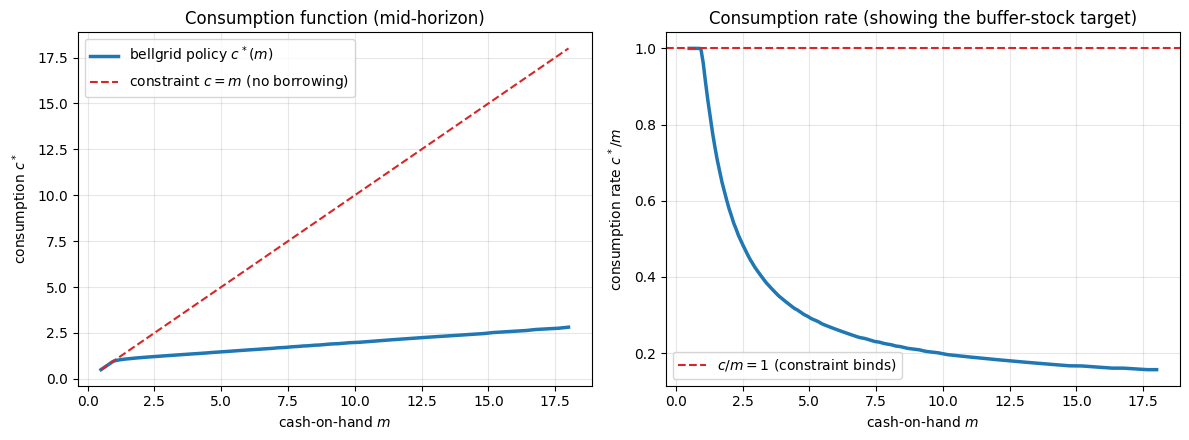

In [4]:
cash_query = torch.linspace(0.5, 18.0, 200, dtype=torch.float64)
consume = policy({"cash": cash_query}, t=T // 2)["consume"].numpy()
cash_np = cash_query.numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot(cash_np, consume, lw=2.5, label="bellgrid policy $c^*(m)$")
ax1.plot(cash_np, cash_np, ls="--", color="C3", lw=1.5,
         label="constraint $c = m$ (no borrowing)")
ax1.set_xlabel("cash-on-hand $m$")
ax1.set_ylabel("consumption $c^*$")
ax1.set_title("Consumption function (mid-horizon)")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(cash_np, consume / cash_np, lw=2.5)
ax2.axhline(1.0, color="C3", ls="--", lw=1.5, label="$c/m = 1$ (constraint binds)")
ax2.set_xlabel("cash-on-hand $m$")
ax2.set_ylabel("consumption rate $c^* / m$")
ax2.set_title("Consumption rate (showing the buffer-stock target)")
ax2.legend()
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Marginal propensity to consume

$\mathrm{MPC}(m) = \partial c^*(m)/\partial m$. Approaches 1 at low cash
(constraint binding) and drops below 0.5 quickly. Standard calibrations
in the literature report MPC in the 0.2 – 0.5 range at typical wealth
levels.

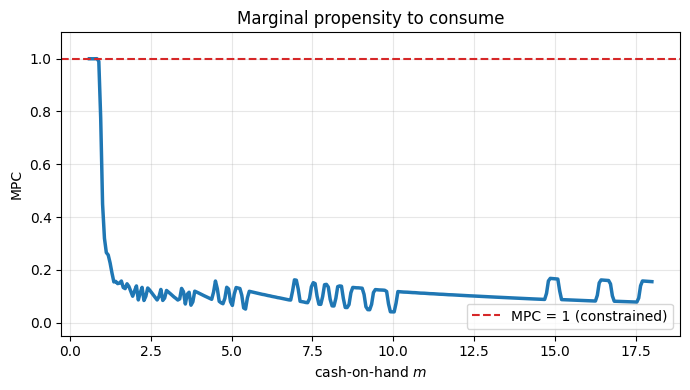

In [5]:
h = 0.05
cash_mpc = torch.linspace(0.6, 18.0, 300, dtype=torch.float64)
c_plus = policy({"cash": cash_mpc + h}, t=T // 2)["consume"]
c_minus = policy({"cash": cash_mpc - h}, t=T // 2)["consume"]
mpc = ((c_plus - c_minus) / (2 * h)).numpy()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(cash_mpc.numpy(), mpc, lw=2.5)
ax.axhline(1.0, color="C3", ls="--", lw=1.5, label="MPC = 1 (constrained)")
ax.set_xlabel("cash-on-hand $m$")
ax.set_ylabel("MPC")
ax.set_title("Marginal propensity to consume")
ax.set_ylim(-0.05, 1.1)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Forward simulation: buffer-stock dynamics

Starting from cash near the constraint, the household accumulates a
buffer over time. Mean cash rises and stabilizes around a stationary
level — this is the Carroll target.

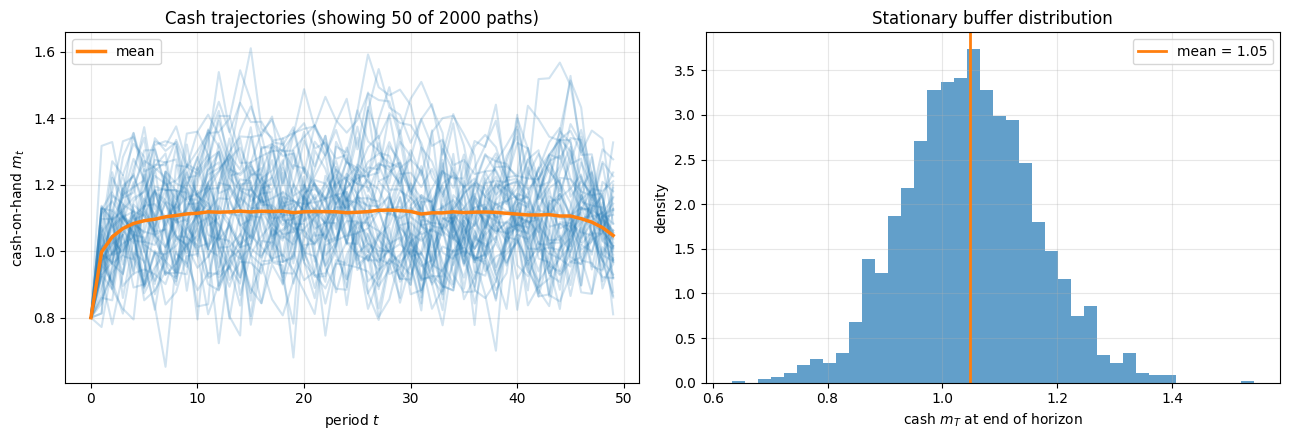

In [6]:
T_long = 50
problem_long = Problem(
    states=problem.states,
    actions=problem.actions,
    transition=transition,
    reward=reward,
    shocks=problem.shocks,
    horizon=range(0, T_long),
    discount=beta,
)
policy_long, _ = solve(
    problem_long,
    state_grid={"cash": WarpedGrid(n=128)},
    action_grid={"consume": RegularGrid(n=500)},
    solver=BackwardInduction(n_quad=7),
)

paths = simulate(
    policy=policy_long,
    problem=problem_long,
    n=2000,
    initial_state={"cash": 0.8},
    seed=0,
)
paths_cpu = {k: v.cpu() for k, v in paths.items()}

cash_paths = paths_cpu["cash"].numpy()
t_axis = np.arange(T_long)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.plot(t_axis, cash_paths[:50].T, color="C0", alpha=0.2)
ax1.plot(t_axis, cash_paths.mean(axis=0), color="C1", lw=2.5, label="mean")
ax1.set_xlabel("period $t$")
ax1.set_ylabel("cash-on-hand $m_t$")
ax1.set_title(f"Cash trajectories (showing 50 of {len(cash_paths)} paths)")
ax1.legend()
ax1.grid(alpha=0.3)

# Distribution of cash at end of horizon
ax2.hist(cash_paths[:, -1], bins=40, density=True, alpha=0.7, color="C0")
ax2.axvline(cash_paths[:, -1].mean(), color="C1", lw=2, label=f"mean = {cash_paths[:, -1].mean():.2f}")
ax2.set_xlabel("cash $m_T$ at end of horizon")
ax2.set_ylabel("density")
ax2.set_title("Stationary buffer distribution")
ax2.legend()
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()